# Preprocesamiento de Datos para Fallas de Dispositivos Médicos

En este notebook, exploraremos un conjunto de datos que contiene información sobre fallas de dispositivos médicos. Nuestro objetivo es preparar los datos para análisis posteriores y aprendizaje automático realizando pasos de preprocesamiento esenciales.

Seguiremos las mejores prácticas descritas en *Python for Data Analysis* de Wes McKinney. Seguiremos los pasos usuales de un proyecto de análisis:

- Verificar y manejar datos faltantes
- Visualizar variables numéricas
- Eliminar registros duplicados
- Agrupar datos por características categóricas
- Aplicar transformaciones logarítmicas y exponenciales
- Escalar datos numéricos
- Codificar variables categóricas

El conjunto de datos consta de más de 1000 registros de dispositivos médicos con varios atributos, como tipo de dispositivo, fabricante, modelo, fecha de compra, antigüedad, costo de mantenimiento, tiempo de inactividad, eventos de falla e informes de mantenimiento.



---

## 📌 1: Exploración y Limpieza Inicial de Datos

Lo primero será cargar datos, inspeccionarlos, manejo de valores faltantes, visualización de distribución, eliminación de duplicados y realizar operaciones de agrupacion.

---

### 1.1 Cargar el Conjunto de Datos

Comenzamos importando las bibliotecas necesarias y cargando el archivo CSV.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar el conjunto de datos
df = pd.read_csv('Medical_Device_Failure_dataset.csv')

# Mostrar las primeras filas
df.head()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar el conjunto de datos
df = pd.read_csv('/content/Medical_Device_Failure_dataset.csv')

# Mostrar las primeras filas
df.head()

,Device_ID,Device_Type,Purchase_Date,Age,Manufacturer,Model,Country,Maintenance_Cost,Downtime,Maintenance_Frequency,Failure_Event_Count,Maintenance_Class,Maintenance_Report
0,MD03449,Defibrillator,2018-04-23,7,CardioSync,Model-100,France,7115.349585,7.933824,3,0,1,Component component upgrade after detecting ov...
1,MD02024,Infusion Pump,2020-12-10,5,MedEquip,Model-650,Italy,7290.780658,7.838711,3,4,2,battery wear caused operational delay; replace...
2,MD04239,MRI Scanner,2023-11-22,2,ImagingTech,Model-650,France,5635.521788,13.911045,1,2,3,data lag caused operational delay; component u...
3,MD00153,Defibrillator,2021-03-03,4,RescueTech,Model-450,UK,5001.360188,29.059510,3,1,3,Routine check completed; battery wear observed...
4,MD03743,Defibrillator,2019-05-16,6,RescueTech,Model-450,Canada,7555.132928,13.942355,4,4,2,Component inspection after detecting voltage s...


In [3]:
#Verificamos el tipo de variables (Device_ID es categorico)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4149 entries, 0 to 4148
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Device_ID              4149 non-null   object 
 1   Device_Type            4149 non-null   object 
 2   Purchase_Date          4149 non-null   object 
 3   Age                    4149 non-null   int64  
 4   Manufacturer           4149 non-null   object 
 5   Model                  4149 non-null   object 
 6   Country                4149 non-null   object 
 7   Maintenance_Cost       4149 non-null   float64
 8   Downtime               4149 non-null   float64
 9   Maintenance_Frequency  4149 non-null   int64  
 10  Failure_Event_Count    4149 non-null   int64  
 11  Maintenance_Class      4149 non-null   int64  
 12  Maintenance_Report     4149 non-null   object 
dtypes: float64(2), int64(4), object(7)
memory usage: 421.5+ KB


## 1.2 Verificar Valores Faltantes
Es esencial saber si hay valores faltantes. Usaremos `isnull().sum()` para contar los nulos por columna.

In [4]:
# Verificar valores faltantes
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])  # mostrar solo columnas con nulos

Series([], dtype: int64)


## 1.3 Visualizar Variables Numéricas
Una vez que tenemos la noción de los datos de manera general y verificamos que no tiene valores ausentes, visualizaremos la distribución de las características numéricas mediante histogramas.

<Figure size 500x600 with 0 Axes>

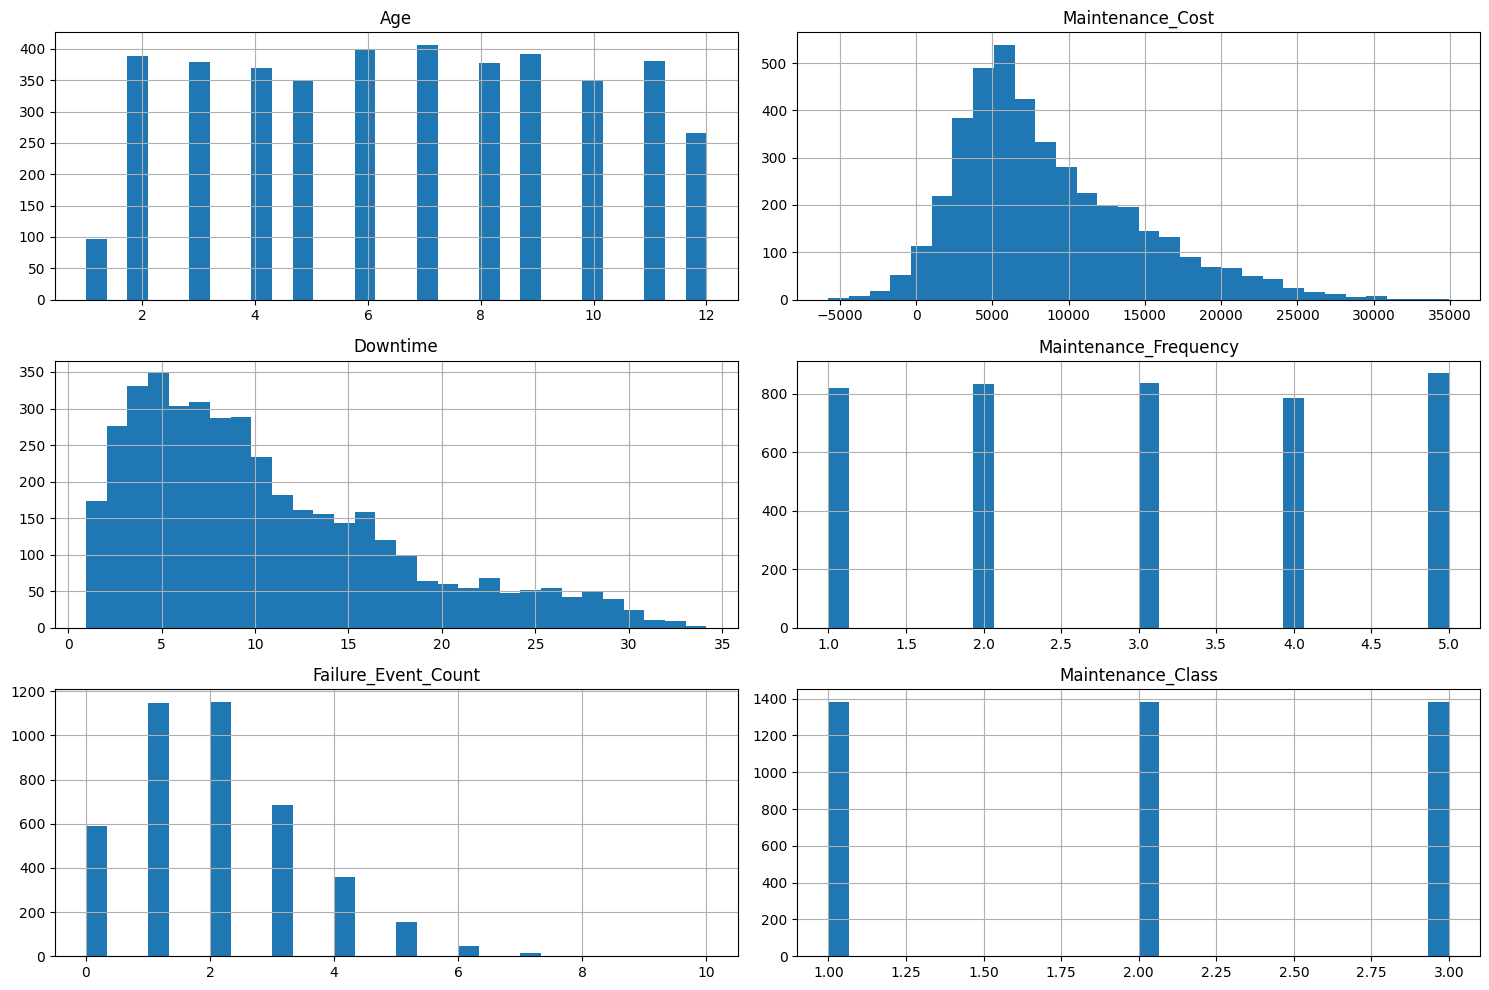

In [5]:
# Seleccionar columnas numéricas (excluyendo ID y fecha)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Eliminar 'Device_ID' y 'Maintenance_Class' si son numéricos pero no continuos
# Device_ID es un identificador; Maintenance_Class es ordinal, pero lo mantendremos por ahora
# También incluiremos 'Age', que es numérico y en este contexto, indica el tiempo de
#uso  desde la fabricación del dispositivo.

# Hacer histogramas
plt.figure(figsize=(5, 6))
df[numerical_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

Observación: Algunas variables como `Maintenance_Cost`, `Downtime` y `Failure_Event_Count` están sesgadas a la derecha. Esto indica que podríamos necesitar una transformación más adelante.

## 1.4 Verificar Registros Duplicados
Los registros duplicados pueden sesgar nuestro análisis. Verifiquemos si hay duplicados y eliminémoslos si existen.

In [6]:
# Verificar filas duplicadas
duplicates = df.duplicated().sum()
print(f"Número de filas duplicadas: {duplicates}")

# Eliminar duplicados si existen
df = df.drop_duplicates()
print(f"Dataset después de eliminar duplicados: {df.shape}")

Número de filas duplicadas: 0
Dataset después de eliminar duplicados: (4149, 13)


## 1.5 Agrupación por Variables Categóricas
La agrupación nos permite resumir datos por categorías. Agruparemos por `Device_Type`, `Manufacturer` y `Model` para ver el costo de mantenimiento promedio, el tiempo de inactividad, etc.

In [7]:
# Agrupar por Device_Type
group_device = df.groupby('Device_Type').agg({
    'Maintenance_Cost': 'mean',
    'Downtime': 'mean',
    'Failure_Event_Count': 'mean'
}).round(2)
print("Promedio por Tipo de Dispositivo:")
print(group_device)

# Agrupar por Manufacturer
group_manufacturer = df.groupby('Manufacturer').agg({
    'Maintenance_Cost': 'mean',
    'Downtime': 'mean',
    'Failure_Event_Count': 'mean'
}).round(2)
print("\nPromedio por Fabricante:")
print(group_manufacturer)

# Agrupar por Model
group_model = df.groupby('Model').agg({
    'Maintenance_Cost': 'mean',
    'Downtime': 'mean',
    'Failure_Event_Count': 'mean'
}).round(2)
print("\nPromedio por Modelo:")
print(group_model.head(10))  # mostrar los primeros 10

Promedio por Tipo de Dispositivo:
               Maintenance_Cost  Downtime  Failure_Event_Count
Device_Type                                                   
CT Scanner              8850.39     10.34                 1.91
Defibrillator           8756.37     10.66                 2.03
Infusion Pump           8430.29     10.62                 2.00
MRI Scanner             8481.51     10.46                 1.93
PET Scanner             8773.51     11.04                 1.93
X-Ray Machine           8582.28     10.60                 1.94

Promedio por Fabricante:
              Maintenance_Cost  Downtime  Failure_Event_Count
Manufacturer                                                 
CardioSync             8600.36     10.70                 1.88
ImagingTech            8671.55     10.69                 1.98
MedEquip               8362.15     10.64                 2.01
RescueTech             8668.73     10.65                 1.96
ScanPro                8602.31     10.49                 1.91
Ul

### 1.5.1 Parte Práctica:
Agrupa los datos por `Country` y `Maintenance_Class`. ¿Cuáles son los costos de mantenimiento promedio y los tiempos de inactividad para cada país y clase de mantenimiento?

¿Podrías identificar alguna otra variable con la que podemos agrupar?

In [8]:
## Tu código aquí ##

#📌 2: Transformaciones, Escalado y Codificación

Transformar datos sesgados, escalar características numéricas y codificar variables categóricas puede tener efectos en el modelado analítico, así que veremos algunos de estos temas en esta sesión.

## 2.1 Visualización de Datos Antes de la Transformación

Antes de transformar, visualicemos la distribución de las columnas numéricas objetivo (ej. `Maintenance_Cost`y `Downtime`; `Failure_Event_Count` **no afecta tanto nuestro análisis**, por ahora...)

Esta vez, usando diagramas de caja para ver valores atípicos.

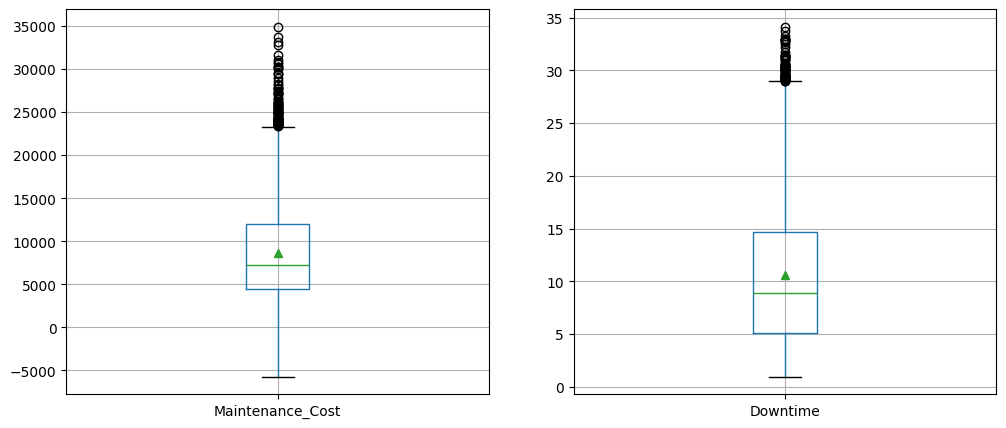

In [9]:
# Diagrama de caja de Maintenance_Cost y Downtime
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df.boxplot(column='Maintenance_Cost', ax=axes[0], showmeans=True)
df.boxplot(column='Downtime', ax=axes[1], showmeans=True)
plt.show()



> Observación: Estas variables tienen valores atípicos extremos, lo que puede afectar el análisis. Las transformaciones pueden ayudar a quitar este efecto.



## 2.2 Transformación de Datos (Logarítmica y Exponencial)

¿Por qué transformar?

- Para hacer que las distribuciones sesgadas sean más simétricas (parecidas a la normal).

- Para estabilizar la varianza.

- Para manejar relaciones exponenciales.

Aplicaremos una transformación logarítmica a `Maintenance_Cost`y `Downtime` (ya que son positivas y están sesgadas).

> Nota: el log de 0 no está definido, por lo que añadimos una pequeña constante si es necesario (pero aquí los valores son > 0).

/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


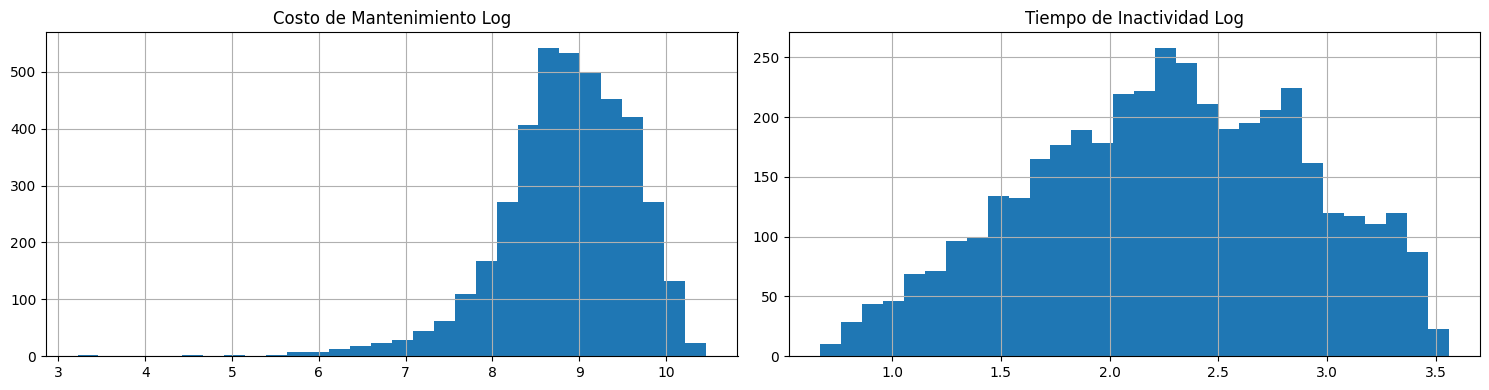

In [10]:
# Aplicar transformación logarítmica (log natural)
df['Log_Maintenance_Cost'] = np.log(df['Maintenance_Cost'] + 1)  # +1 para evitar log(0)
df['Log_Downtime'] = np.log(df['Downtime'] + 1)

# Mostrar histogramas de las variables transformadas
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

df['Log_Maintenance_Cost'].hist(ax=axes[0], bins=30)
axes[0].set_title('Costo de Mantenimiento Log')

df['Log_Downtime'].hist(ax=axes[1], bins=30)
axes[1].set_title('Tiempo de Inactividad Log')

plt.tight_layout()
plt.show()

## 2.3 Escalado de Datos

Escalar datos permite llevar todas las características a un rango similar, evitando que las características con magnitudes mayores dominen en algoritmos basados en distancias.

Métodos comunes: Escalado Min-Max (normalización) y Estandarización (puntuación Z).

Aplicaremos ambos manualmente.



In [11]:
# Escalado Min-Max (normalización) para características seleccionadas
features_to_scale = ['Maintenance_Cost', 'Downtime', 'Age']
for col in features_to_scale:
    min_val = df[col].min()
    max_val = df[col].max()
    df[col + '_minmax'] = (df[col] - min_val) / (max_val - min_val)

# Estandarización (puntuación Z)
for col in features_to_scale:
    mean_val = df[col].mean()
    std_val = df[col].std()
    df[col + '_zscore'] = (df[col] - mean_val) / std_val

# Mostrar estadísticas resumidas de las versiones original y escaladas
print(df[['Maintenance_Cost', 'Maintenance_Cost_minmax', 'Maintenance_Cost_zscore']].describe())
print(df[['Downtime', 'Downtime_minmax', 'Downtime_zscore']].describe())
print(df[['Age', 'Age_minmax', 'Age_zscore']].describe())

       Maintenance_Cost  Maintenance_Cost_minmax  Maintenance_Cost_zscore
count       4149.000000              4149.000000             4.149000e+03
mean        8643.595669                 0.353729             1.442835e-16
std         5930.038551                 0.145754             1.000000e+00
min        -5747.932890                 0.000000            -2.426886e+00
25%         4451.775127                 0.250699            -7.068791e-01
50%         7213.575604                 0.318581            -2.411485e-01
75%        12023.912821                 0.436814             5.700329e-01
max        34937.222389                 1.000000             4.433972e+00
          Downtime  Downtime_minmax  Downtime_zscore
count  4149.000000      4149.000000     4.149000e+03
mean     10.621367         0.291282    -2.003700e-16
std       7.099434         0.213822     1.000000e+00
min       0.950068         0.000000    -1.362263e+00
25%       5.066061         0.123966    -7.824998e-01
50%       8.8623

Veamos ahora estas variables luego del escalamiento y transformación.

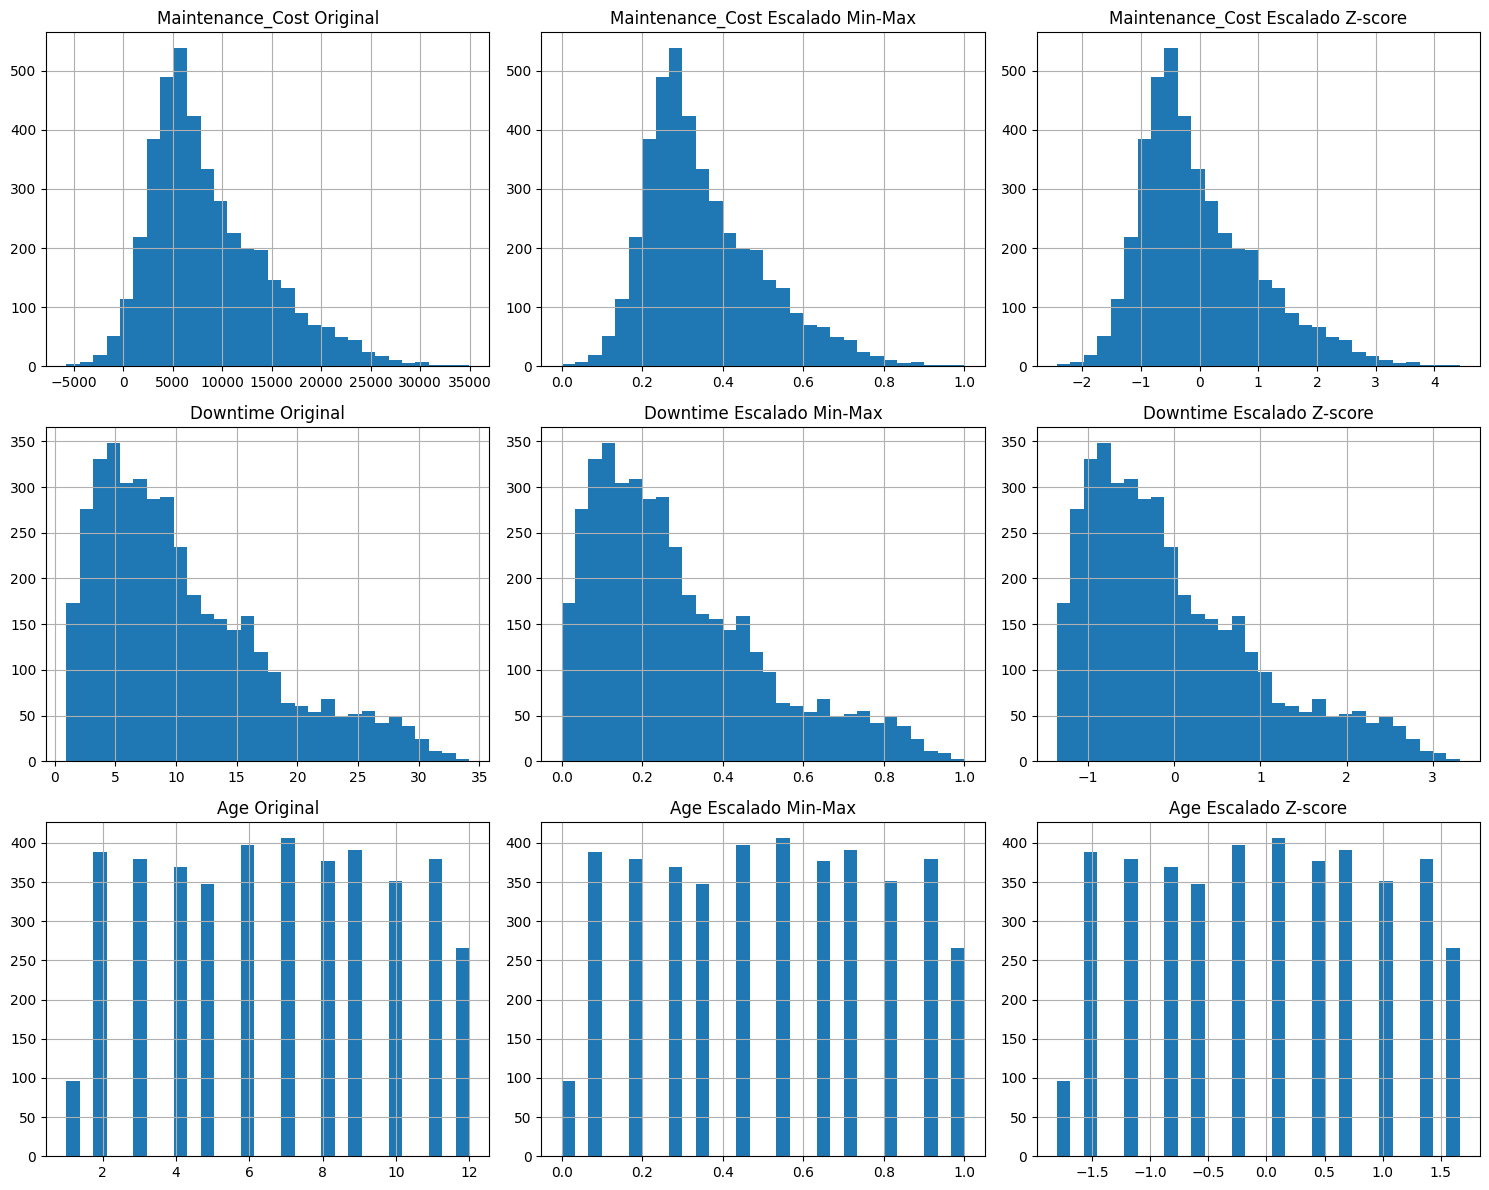

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Maintenance_Cost
df['Maintenance_Cost'].hist(ax=axes[0, 0], bins=30)
axes[0, 0].set_title('Maintenance_Cost Original')
df['Maintenance_Cost_minmax'].hist(ax=axes[0, 1], bins=30)
axes[0, 1].set_title('Maintenance_Cost Escalado Min-Max')
df['Maintenance_Cost_zscore'].hist(ax=axes[0, 2], bins=30)
axes[0, 2].set_title('Maintenance_Cost Escalado Z-score')

# Downtime
df['Downtime'].hist(ax=axes[1, 0], bins=30)
axes[1, 0].set_title('Downtime Original')
df['Downtime_minmax'].hist(ax=axes[1, 1], bins=30)
axes[1, 1].set_title('Downtime Escalado Min-Max')
df['Downtime_zscore'].hist(ax=axes[1, 2], bins=30)
axes[1, 2].set_title('Downtime Escalado Z-score')

# Age
df['Age'].hist(ax=axes[2, 0], bins=30)
axes[2, 0].set_title('Age Original')
df['Age_minmax'].hist(ax=axes[2, 1], bins=30)
axes[2, 1].set_title('Age Escalado Min-Max')
df['Age_zscore'].hist(ax=axes[2, 2], bins=30)
axes[2, 2].set_title('Age Escalado Z-score')

plt.tight_layout()
plt.show()

> Nota para recordar: El Escalamiento **NO** afecta la distribución de las variables. La Transformación si.

Pregunta clave: ¿Qué deberíamos hacer primero cuando estamos realizando un proyecto de ciencia de datos: Transformación o escalamiento?

###2.3.1 Escalado de Variables Transformadas

¿Por qué escalar después de transformar?

La transformación logarítmica corrige la asimetría y estabiliza la varianza, pero las magnitudes de las variables transformadas aún pueden diferir entre sí.

Por ejemplo, `Log_Maintenance_Cost` puede tener valores entre 0 y 12, mientras que `Log_Downtime` puede estar entre 0 y 4.

Si nuestra intención es usar algoritmos basados en distancias (como k‑NN o regresión logística con regularización), es conveniente que todas las características estén en rangos comparables.

Por eso, después de la transformación, aplicamos escalado.



In [13]:
#Seleccionamos las columnas que ya fueron transformadas con log
log_features = ['Log_Maintenance_Cost', 'Log_Downtime']

# También podríamos incluir Log_Maintenance_Frequency si se creó en la práctica
# Pero aquí solo usamos dos principales

# 1. Escalado Min‑Max (normalización)
for col in log_features:
    min_val = df[col].min()
    max_val = df[col].max()
    df[col + '_minmax'] = (df[col] - min_val) / (max_val - min_val)

# 2. Estandarización Z‑score
for col in log_features:
    mean_val = df[col].mean()
    std_val = df[col].std()
    df[col + '_zscore'] = (df[col] - mean_val) / std_val

# Mostrar estadísticas descriptivas de las versiones transformadas y escaladas
print(df[['Log_Maintenance_Cost', 'Log_Maintenance_Cost_minmax', 'Log_Maintenance_Cost_zscore']].describe())
print(df[['Log_Downtime', 'Log_Downtime_minmax', 'Log_Downtime_zscore']].describe())


       Log_Maintenance_Cost  Log_Maintenance_Cost_minmax  \
count           4044.000000                  4044.000000   
mean               8.852076                     0.777787   
std                0.777344                     0.107339   
min                3.219368                     0.000000   
25%                8.444277                     0.721476   
50%                8.909274                     0.785685   
75%                9.407086                     0.854425   
max               10.461337                     1.000000   

       Log_Maintenance_Cost_zscore  
count                 4.044000e+03  
mean                  1.102536e-15  
std                   1.000000e+00  
min                  -7.246095e+00  
25%                  -5.246064e-01  
50%                   7.358082e-02  
75%                   7.139820e-01  
max                   2.070204e+00  
       Log_Downtime  Log_Downtime_minmax  Log_Downtime_zscore
count   4149.000000          4149.000000         4.149000e+03
me

Comparemos resultados, es decir las variables escaladas transformadas vs. solo las variables escaladas.


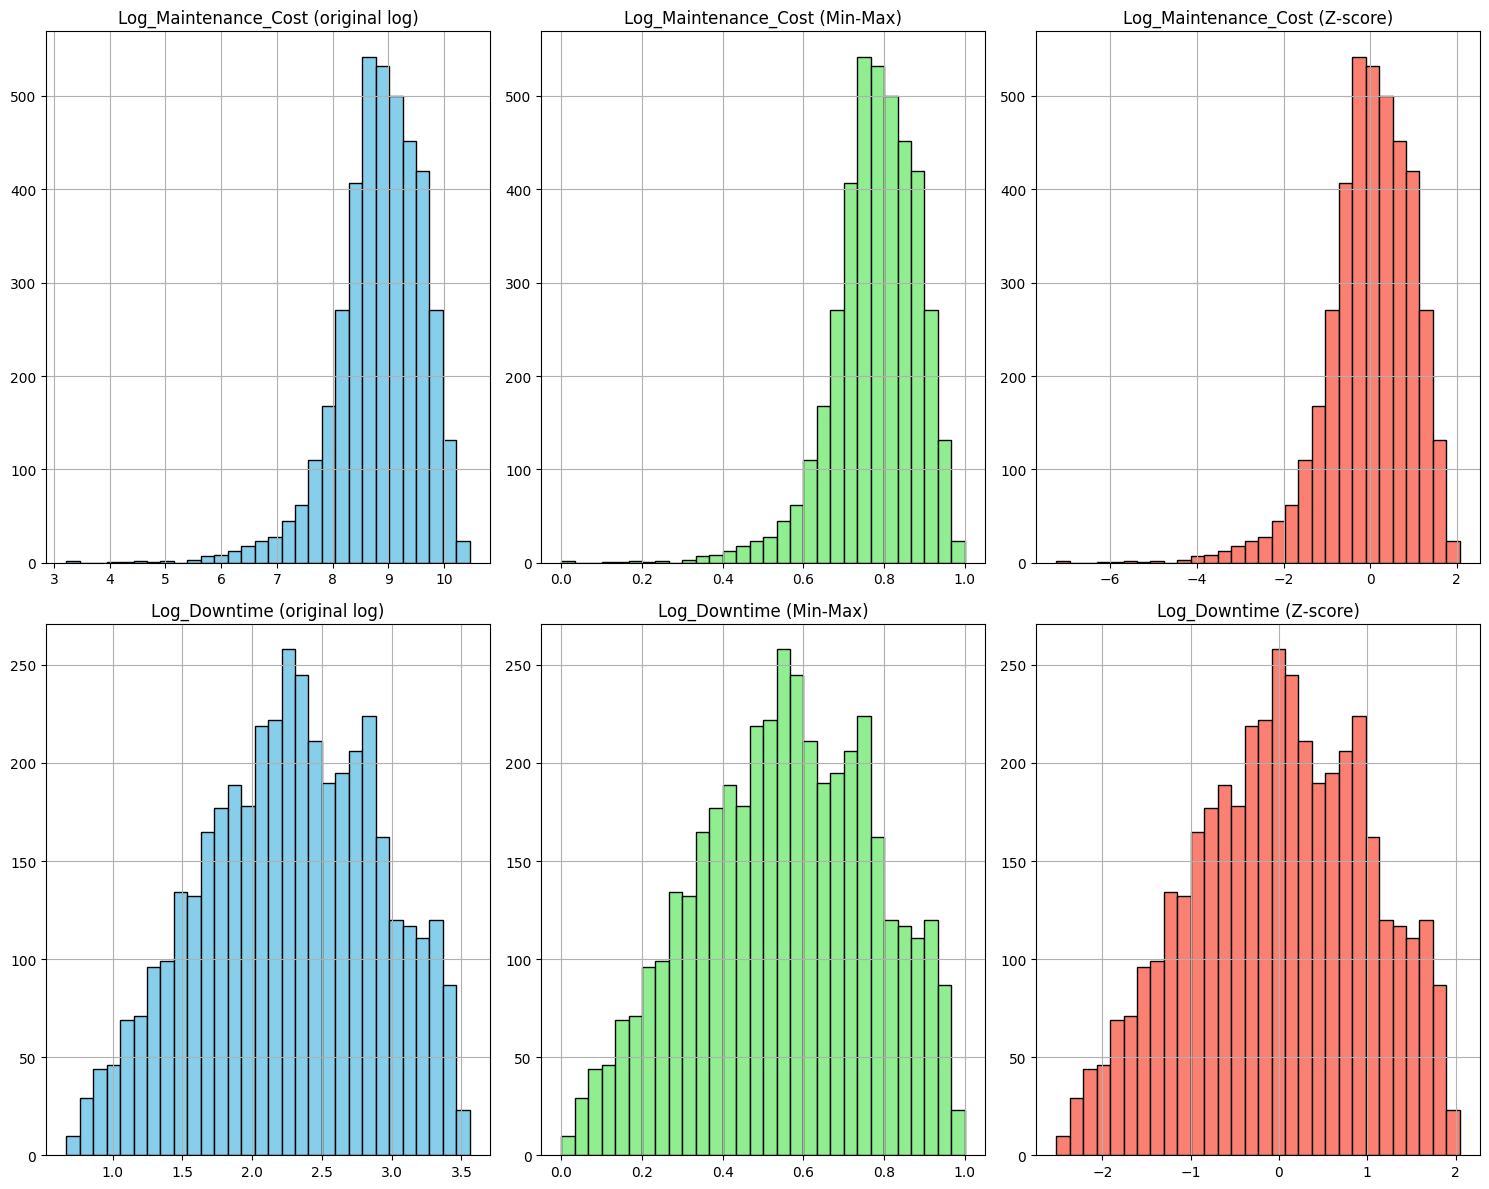

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 12))

# Para cada variable transformada, mostramos: original log, Min‑Max, Z‑score
for i, col in enumerate(log_features):
    # Log original
    df[col].hist(ax=axes[i, 0], bins=30, color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f'{col} (original log)')

    # Min‑Max
    df[col + '_minmax'].hist(ax=axes[i, 1], bins=30, color='lightgreen', edgecolor='black')
    axes[i, 1].set_title(f'{col} (Min‑Max)')

    # Z‑score
    df[col + '_zscore'].hist(ax=axes[i, 2], bins=30, color='salmon', edgecolor='black')
    axes[i, 2].set_title(f'{col} (Z‑score)')

plt.tight_layout()
plt.show()

Observaciones:

> La escala Min‑Max comprime todos los valores en el intervalo [0, 1], manteniendo la forma de la distribución original (la asimetría ya corregida por el log).

> La estandarización Z‑score centra la media en 0 y la desviación estándar en 1, también preservando la forma.

> Ambas técnicas hacen que las características sean comparables en magnitud, lo que beneficia a muchos modelos.


# 📌 3: Codificación de Datos


Los algoritmos de aprendizaje automático suelen requerir entradas numéricas (regresiones generales, SVM y redes neuronales)

De manera que las variables categóricas (en este ejemplo: `Device_Type`, `Manufacturer`, `Model`, `Country`, `Maintenance_Class`) deben convertirse a números.

Demostraremos dos métodos:

Codificación por Etiquetas (asigna enteros a las categorías) – adecuada para datos ordinales.

Codificación One-Hot (crea columnas binarias para cada categoría) – adecuada para datos nominales.

Aplicaremos codificación one-hot a `Device_Type`, `Manufacturer`, `Model`, `Country`. Para `Maintenance_Class`, que ya es numérica pero ordinal, podríamos dejarla como está o aplicar codificación por etiquetas (ya que tenemos números).

La trataremos como categórica y quizás le aplicaremos codificación one-hot también para demostración.

In [15]:
# Codificación one-hot para columnas categóricas
categorical_cols = ['Device_Type', 'Manufacturer', 'Model', 'Country', 'Maintenance_Class']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# Mostrar forma y primeras columnas
print(f"Forma después de la codificación one-hot: {df_encoded.shape}")
df_encoded.head()

Forma después de la codificación one-hot: (4149, 53)


,Device_ID,Purchase_Date,Age,Maintenance_Cost,Downtime,Maintenance_Frequency,Failure_Event_Count,Maintenance_Report,Log_Maintenance_Cost,Log_Downtime,...,Model_Model-650,Country_Canada,Country_France,Country_Italy,Country_Japan,Country_UK,Country_USA,Maintenance_Class_1,Maintenance_Class_2,Maintenance_Class_3
0,MD03449,2018-04-23,7,7115.349585,7.933824,3,0,Component component upgrade after detecting ov...,8.870150,2.189845,...,False,False,True,False,False,False,False,True,False,False
1,MD02024,2020-12-10,5,7290.780658,7.838711,3,4,battery wear caused operational delay; replace...,8.894503,2.179141,...,True,False,False,True,False,False,False,False,True,False
2,MD04239,2023-11-22,2,5635.521788,13.911045,1,2,data lag caused operational delay; component u...,8.637022,2.702102,...,True,False,True,False,False,False,False,False,False,True
3,MD00153,2021-03-03,4,5001.360188,29.059510,3,1,Routine check completed; battery wear observed...,8.517665,3.403179,...,False,False,False,False,False,True,False,False,False,True
4,MD03743,2019-05-16,6,7555.132928,13.942355,4,4,Component inspection after detecting voltage s...,8.930115,2.704200,...,False,True,False,False,False,False,False,False,True,False


## 3.1 ¿Qué es la Codificación por Etiquetas (Label Encoding)?


La codificación por etiquetas consiste en asignar un número entero único a cada categoría de una variable categórica. Por ejemplo:

Rojo → 0

Verde → 1

Azul → 2

Es útil cuando la variable tiene un orden intrínseco (ordinal), como niveles de educación (bajo, medio, alto) o tamaños (pequeño, mediano, grande). Sin embargo, si la variable es nominal (sin orden), como colores o países, la codificación por etiquetas puede introducir un orden artificial que el modelo podría interpretar erróneamente. En esos casos, es mejor usar one‑hot encoding.

In [16]:

# Datos de ejemplo
data = {'Talla': ['S', 'M', 'L', 'XL', 'M', 'S', 'L']}
df_ejemplo = pd.DataFrame(data)
print("Datos originales:")
print(df_ejemplo)

Datos originales:
  Talla
0     S
1     M
2     L
3    XL
4     M
5     S
6     L


Ahora creamos un diccionario de mapeo para asignar números a cada talla (respetando el orden: S=1, M=2, L=3, XL=4):

In [17]:
# Mapeo manual
mapeo_tallas = {'S': 1, 'M': 2, 'L': 3, 'XL': 4}
df_ejemplo['Talla_codificada'] = df_ejemplo['Talla'].map(mapeo_tallas)
print("Datos con codificación por etiquetas:")
print(df_ejemplo)

Datos con codificación por etiquetas:
  Talla  Talla_codificada
0     S                 1
1     M                 2
2     L                 3
3    XL                 4
4     M                 2
5     S                 1
6     L                 3


Alternativamente, podríamos usar `pd.categorical` para asignar códigos automáticamente.

In [18]:
df_ejemplo['Talla_codificada_auto'] = pd.Categorical(df_ejemplo['Talla'],
                        categories=['S','M','L','XL'],
                        ordered=True).codes + 1

In [19]:
df_ejemplo

,Talla,Talla_codificada,Talla_codificada_auto
0,S,1,1
1,M,2,2
2,L,3,3
3,XL,4,4
4,M,2,2
5,S,1,1
6,L,3,3


### 3.1.1 Práctica de codificación:

1. Crea un mapeo para la columna Country y asígnale un código numérico.

¿Qué columna crees que es más adecuada para label encoding y cuál para one‑hot? Justifica tu respuesta.

# 4. Combinar Resultados y guardar dataset

# Actividad – Preprocesamiento Integral de Datos Médicos

Entrega: Jueves 3 de septiembre
Formato: Notebook de Jupyter (.ipynb) con código, explicaciones y salidas.

## 🎯 Objetivo
Aplicarás todas las técnicas de preprocesamiento vistas en clase sobre un conjunto de datos médico de tu elección entre las 5 opciones disponibles en Kaggle (Si gustan escoger otro, adelante).

El resultado final será un dataset limpio, transformado, escalado, codificado y enriquecido con nuevas características, listo para ser utilizado en modelos de aprendizaje automático.

Además, realizarás un análisis exploratorio inicial que incluye visualizaciones, estadísticas y agrupaciones para entender la naturaleza de los datos.


### Enlaces directos a los datasets
1. Heart Disease Prediction: Datos clínicos para predecir enfermedades cardíacas. Incluye edad, sexo, tipo de dolor de pecho, colesterol, frecuencia cardíaca, etc. ~1,000 registros, 14 variables.

🔗 https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

2. Diabetes Prediction Dataset: Datos de diagnóstico para predicción de diabetes. Incluye embarazos, glucosa, presión arterial, IMC, edad, etc. ~100,000 registros, 9 variables.

🔗 https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset

3. Medical Cost Personal Dataset:
Datos de seguros de salud para predecir costos médicos. Incluye edad, sexo, IMC, hijos, hábito de fumar, región, etc. ~1,338 registros, 7 variables.

🔗 https://www.kaggle.com/datasets/mirichoi0218/insurance

4. Brain Stroke Dataset: Datos demográficos y de salud para predecir riesgo de derrame cerebral. Incluye edad, género, hipertensión, enfermedad cardíaca, tipo de trabajo, glucosa, IMC, etc. ~5,000 registros, 11 variables.

🔗 https://www.kaggle.com/datasets/zzettrkalpakbal/full-filled-brain-stroke-dataset

5. Breast Cancer Wisconsin Dataset:
Datos de diagnóstico de cáncer de mama (clasificación benigno/maligno). Incluye 30 características numéricas derivadas de imágenes digitalizadas de aspirados con aguja fina. ~569 registros, 32 variables.

🔗 https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

📋 Instrucciones Generales
- Elige uno de los 5 datasets listados arriba.

- Descárgalo desde Kaggle (necesitarás una cuenta gratuita).

- Carga el archivo CSV en tu notebook.

- Ejecuta todos los pasos del 1 al 13 descritos a continuación.

- Adapta los nombres de columnas y variables según tu dataset (no todos tienen las mismas columnas).

- Guarda el dataset final como final_prep_data.csv.




## Pasos a seguir

1. Carga del conjunto de datos
Importa las librerías necesarias (pandas, numpy, matplotlib.pyplot).

Carga el archivo CSV en un DataFrame.

Muestra las primeras 5 filas y la información general (info()).

2. Verificación y manejo de valores faltantes

Calcula la cantidad de valores nulos por columna.

Si existen, decide una estrategia (eliminación o imputación) y justifícala.

Sugerencia: Para datos numéricos usa la mediana o el promedio; para categóricos usa la moda.

3. Visualización de variables numéricas

Selecciona todas las columnas numéricas (excluyendo identificadores).

Realiza histogramas para cada una (usa hist() de pandas o matplotlib).

Identifica cuáles presentan alta asimetría (sesgo positivo o negativo).

4. Eliminación de duplicados

Verifica si hay filas duplicadas y elimínalas si existen.

Muestra el número de duplicados encontrados y la forma del DataFrame después de la eliminación.

5. Agrupación y estadísticas por variables categóricas

Elige al menos dos variables categóricas (dependiendo de tu dataset).

Agrupa los datos y calcula: media, mediana y conteo de al menos tres variables numéricas.

Presenta los resultados en tablas (usando groupby() y agg()).

6. Extracción de características desde fechas (si aplica)

Si tu dataset tiene una columna de fecha, conviértela a datetime y extrae año, mes, día, trimestre.

Si no tiene fechas, salta este paso y justifica por qué no aplica.

7. Creación de nuevas características (Feature Engineering)

Genera al menos tres nuevas variables combinando columnas existentes.

Ejemplos:

IMC / Edad

Glucosa * Presión

Costo / Hijos

Justifica por qué estas nuevas variables podrían ser útiles para el análisis.

8. Discretización (Binning)

Toma una variable numérica (por ejemplo, Age o BMI) y divídela en tres o cuatro intervalos (bins) con etiquetas descriptivas.

Crea una nueva columna categórica con estos rangos.

Muestra la distribución de frecuencias de los grupos.

9. Procesamiento de texto básico (NLP) (si aplica)

Si tu dataset tiene una columna de texto, extrae al menos tres palabras clave y crea columnas binarias (0/1) indicando su presencia.

Si no tiene texto, salta este paso y justifica por qué no aplica.

10. Transformación logarítmica

Selecciona al menos dos columnas numéricas sesgadas (identificadas en el paso 3) y aplica la transformación log(1 + x).

Crea nuevas columnas con el prefijo Log_.

Visualiza los histogramas de las versiones transformadas y comenta el cambio en la distribución.

11. Escalado (Estandarización Z‑score)

Elige al menos tres columnas numéricas (pueden ser las transformadas o las originales) y aplica la estandarización (media=0, desviación=1).

Crea nuevas columnas con el sufijo _zscore.

Muestra las estadísticas descriptivas (media, desviación) de las columnas estandarizadas para verificar que quedaron centradas.

12. Codificación One‑Hot

Selecciona al menos tres columnas categóricas (dependiendo de tu dataset).

Aplica codificación one‑hot usando pd.get_dummies() (con drop_first=False).

Muestra la cantidad de columnas nuevas generadas y las primeras filas del DataFrame resultante.

13. Guardado del dataset final

Guarda el DataFrame final (con todas las transformaciones) en un archivo CSV llamado final_prep_data.csv.

Asegúrate de no incluir el índice al guardar (index=False).






## Requisitos de entrega
Notebook Jupyter con celdas de código y celdas de texto (markdown) explicando cada paso.

Todas las salidas deben ser visibles (ejecutar todas las celdas antes de entregar).

Incluye comentarios en el código donde sea necesario.

Añade una conclusión final donde comenten dificultades encontradas y cómo las resolviste/resolvieron.
